#LG Aimers 해커톤: 제구 성공 확률 예측 (Pitch Control Success Prediction)

* **예측 대상 (Target)**: `control_success` (1: 제구 성공, 0: 제구 실패)
* **제약 조건**: 공이 손을 떠난 '이후'에 발생한 데이터(예: 이번 공의 실시간 구속, 타격 결과 등)는 절대 예측 모델의 입력으로 사용할 수 없음. 오로지 과거 누적 기록(`asof_` 및 트랙맨)과 투구 직전의 경기 상황(이닝, 볼카운트 등)만 사용해야 함.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

# 주의: 본인의 구글 드라이브 내 실제 데이터가 위치한 경로로 수정하여 사용하세요.
# 예시: data_path = '/content/drive/MyDrive/LG_Aimers/open/'
# train = pd.read_csv(data_path + 'train.csv')


Mounted at /content/drive


#**EDA : 데이터 분석 및 파악**

* 데이터 주요 변수을 알아보고 결측치와 이상치, 이상값 확인.
* 파악된 각각의 데이터를 어떻게 처리할 지 구상.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 구글 코랩 드라이브 마운트
# from google.colab import drive
# drive.mount('/content/drive')

train_path = '/content/drive/MyDrive/LG_Aimers/train.csv'
train = pd.read_csv(train_path)
print(f"데이터 크기: {train.shape}")

데이터 크기: (1475092, 49)


In [3]:
# [0] 데이터 특성 파악(컬럼 종류, 각각의 수치)
train.describe()

,season,game_month,game_dayofweek,inning,balls_before,strikes_before,outs_before,run_top_before,run_bot_before,run_total_before,...,asof_pitcher_prev3_game_middle_rate,asof_pitcher_prev5_game_middle_rate,asof_batter_n,asof_batter_success_rate,asof_batter_middle_rate,asof_pitcher_pitchmix_n,asof_pitcher_fastball_rate,asof_pitcher_breaking_rate,asof_pitcher_offspeed_rate,control_success
count,1.475092e+06,1.475092e+06,1.475092e+06,1.475092e+06,1.475092e+06,1.475092e+06,1.475092e+06,1.475092e+06,1.475092e+06,1.475092e+06,...,1.445907e+06,1.445907e+06,1.475092e+06,1.474262e+06,1.474262e+06,1.475092e+06,1.474300e+06,1.474300e+06,1.474300e+06,1.475092e+06
mean,2.021529e+03,6.668617e+00,3.508963e+00,4.965961e+00,8.984680e-01,8.718710e-01,9.814317e-01,2.557856e+00,2.357027e+00,4.914883e+00,...,1.493904e-01,1.488919e-01,3.270847e+03,5.397311e-01,1.405063e-01,2.661323e+03,5.543835e-01,2.892743e-01,1.563423e-01,5.237660e-01
std,1.705827e+00,1.927907e+00,1.732295e+00,2.605404e+00,9.697419e-01,8.246053e-01,8.167271e-01,2.914232e+00,2.766365e+00,4.500625e+00,...,5.620127e-02,4.755480e-02,3.049042e+03,5.160833e-02,2.718000e-02,2.690013e+03,9.911775e-02,1.083221e-01,1.084719e-01,4.994350e-01
min,2.019000e+03,3.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.020000e+03,5.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,...,1.111110e-01,1.171370e-01,7.880000e+02,5.154790e-01,1.303190e-01,6.840000e+02,4.864860e-01,2.158587e-01,7.500000e-02,0.000000e+00
50%,2.022000e+03,6.000000e+00,4.000000e+00,5.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,4.000000e+00,...,1.458330e-01,1.461320e-01,2.263000e+03,5.321560e-01,1.419960e-01,1.776000e+03,5.440410e-01,2.893010e-01,1.405625e-01,1.000000e+00
75%,2.023000e+03,8.000000e+00,5.000000e+00,7.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,4.000000e+00,4.000000e+00,7.000000e+00,...,1.828360e-01,1.785710e-01,5.007000e+03,5.551190e-01,1.517000e-01,3.725000e+03,6.136360e-01,3.618010e-01,2.170110e-01,1.000000e+00
max,2.024000e+03,1.000000e+01,6.000000e+00,1.300000e+01,3.000000e+00,2.000000e+00,2.000000e+00,3.000000e+01,2.600000e+01,3.700000e+01,...,1.000000e+00,1.000000e+00,1.392700e+04,1.000000e+00,1.000000e+00,1.544900e+04,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [4]:
# [1] 타겟 불균형 확인 (제구 성공 vs 실패)
print("[1] Target Distribution")
display(train['control_success'].value_counts(normalize=True) * 100)

[1] Target Distribution


,proportion
control_success,
1,52.376598
0,47.623402


### [1] 타겟 불균형 확인
타겟 변수(`control_success`)의 클래스 분포 확인 결과, 제구 성공(1) 52.38%, 제구 실패(0) 47.62%로 산출됨. 클래스 간 비율이 약 1:1 수준으로 균형을 이루고 있으므로, 모델링 단계에서 SMOTE 등 오버샘플링 기법이나 별도의 클래스 가중치(Class Weight) 부여 작업은 요구되지 않음.

In [5]:
# [2] 결측치(Missing Values) 확인
print("[2] Missing Values")
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': (missing / len(train)) * 100})
    display(missing_df)
else:
    print("결측치가 없습니다.")

[2] Missing Values


,Missing Count,Missing %
asof_pitcher_prev3_game_success_rate,29185,1.978521
asof_pitcher_prev5_game_success_rate,29185,1.978521
asof_pitcher_prev1_game_success_rate,29185,1.978521
asof_pitcher_prev1_game_middle_rate,29185,1.978521
asof_pitcher_prev3_game_middle_rate,29185,1.978521
asof_pitcher_prev5_game_middle_rate,29185,1.978521
asof_batter_success_rate,830,0.056268
asof_batter_middle_rate,830,0.056268
asof_pitcher_strike_rate,792,0.053692
asof_pitcher_reverse_rate,792,0.053692


### [2] 결측치(Missing Values) 확인
결측치 탐색 결과, 전체 49개 변수 중 과거 누적 기록을 나타내는 `asof_` 변수군 일부에서만 결측이 발견됨.
- 최근 1~5경기 기록(`asof_pitcher_prev_game_*`): 약 1.98% 결측
- 전체 누적 기록(`asof_pitcher_*`, `asof_batter_*`): 약 0.05% 결측
이는 해당 선수의 과거 등판 표본이 없는 Cold-start(데뷔 첫 등판 등) 상황에 기인한 타당한 결측치로 판단됨. 전체 데이터 대비 결측 비율이 매우 낮으며, 정보 부재 자체가 유의미한 상황적 특성임.

In [6]:
# [3] 야구 도메인 기반 이상값(Anomaly) 탐색

print(f"볼 4 이상 (0이어야 정상): {len(train[train['balls_before'] >= 4])} 건")
print(f"스트라이크 3 이상 (0이어야 정상): {len(train[train['strikes_before'] >= 3])} 건")
print(f"아웃 3 이상 (0이어야 정상): {len(train[train['outs_before'] >= 3])} 건")
print(f"이닝 0 이하 (0이어야 정상): {len(train[train['inning'] <= 0])} 건")

home_win_err = len(train[(train['home_win_expectancy'] < 0) | (train['home_win_expectancy'] > 100)])
print(f"홈팀 기대 승률 0 미만 or 100 초과: {home_win_err} 건")

볼 4 이상 (0이어야 정상): 0 건
스트라이크 3 이상 (0이어야 정상): 0 건
아웃 3 이상 (0이어야 정상): 0 건
이닝 0 이하 (0이어야 정상): 0 건
홈팀 기대 승률 0 미만 or 100 초과: 0 건


### [3] 야구 도메인 기반 이상값(Anomaly) 탐색
'투구 직전 상황'이라는 도메인 규칙을 바탕으로 논리적 오류 데이터를 검증함.
검증 지표는 타석 및 이닝 종료 조건(볼 4 이상, 스트라이크 3 이상, 아웃 3 이상, 이닝 0 이하)과 확률 범위 이탈(기대 승률 0 미만 혹은 100 초과) 여부임.
확인 결과 조건 위반 사례는 0건으로 산출되었으며, 데이터 수집 과정에서의 논리적 결함 및 에러 데이터는 존재하지 않음.

In [7]:
# [4] 과거 기록(asof_rate) 비율 변수 극단값 탐색
rate_cols = [col for col in train.columns if 'asof_' in col and 'rate' in col]
display(train[rate_cols].describe().T[['min', 'max', 'mean']])

,min,max,mean
asof_pitcher_success_rate,0.0,1.0,0.535228
asof_pitcher_reverse_rate,0.0,1.0,0.215210
asof_pitcher_middle_rate,0.0,1.0,0.141865
asof_pitcher_ball_rate,0.0,1.0,0.372243
asof_pitcher_strike_rate,0.0,1.0,0.441876
asof_pitcher_prev1_game_success_rate,0.0,1.0,0.523354
asof_pitcher_prev3_game_success_rate,0.0,1.0,0.523848
asof_pitcher_prev5_game_success_rate,0.0,1.0,0.524411
asof_pitcher_prev1_game_middle_rate,0.0,1.0,0.150606
asof_pitcher_prev3_game_middle_rate,0.0,1.0,0.149390


### [4] 과거 기록(asof_rate) 비율 변수 극단값 탐색
비율(Rate) 속성을 지닌 `asof_*_rate` 변수들의 최솟값(min)과 최댓값(max)을 검증함.
검사 대상인 모든 변수가 비율 데이터의 정상 범위인 0.0과 1.0 사이에 위치함. 음수나 1.0을 초과하는 아웃라이어는 발견되지 않았으므로 별도의 스케일링이나 보정이 불필요함.


▶ [score_diff_home]
- IQR 기준 (Lower: -6.5, Upper: 5.5)
  └ 극단값 개수: 138,418개 (9.38%)
- ESD 기준 (Mean ± 3*Std)
  └ 극단값 개수: 17,987개 (1.22%)

▶ [asof_pitcher_n]
- IQR 기준 (Lower: -3877.5, Upper: 8286.5)
  └ 극단값 개수: 81,418개 (5.52%)
- ESD 기준 (Mean ± 3*Std)
  └ 극단값 개수: 27,771개 (1.88%)

▶ [asof_batter_n]
- IQR 기준 (Lower: -5540.5, Upper: 11335.5)
  └ 극단값 개수: 22,756개 (1.54%)
- ESD 기준 (Mean ± 3*Std)
  └ 극단값 개수: 6,930개 (0.47%)


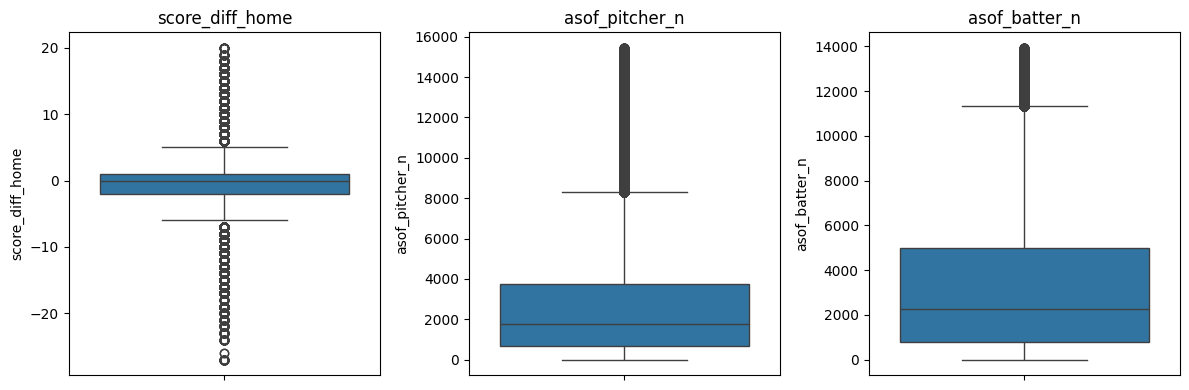

In [8]:
# [5] 통계적 극단값 탐색 (IQR & ESD)

# 극단값을 확인할 주요 연속형 변수들
check_cols = ['score_diff_home', 'asof_pitcher_n', 'asof_batter_n']
for col in check_cols:
    # 1. IQR (4분위수) 방식 계산
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_iqr = train[(train[col] < lower_bound) | (train[col] > upper_bound)]

    # 2. ESD (Z-score, 3표준편차) 방식 계산
    mean_val = train[col].mean()
    std_val = train[col].std()
    outliers_z = train[(train[col] < mean_val - 3*std_val) | (train[col] > mean_val + 3*std_val)]

    print(f"\n▶ [{col}]")
    print(f"- IQR 기준 (Lower: {lower_bound:.1f}, Upper: {upper_bound:.1f})")
    print(f"  └ 극단값 개수: {len(outliers_iqr):,}개 ({len(outliers_iqr)/len(train)*100:.2f}%)")
    print(f"- ESD 기준 (Mean ± 3*Std)")
    print(f"  └ 극단값 개수: {len(outliers_z):,}개 ({len(outliers_z)/len(train)*100:.2f}%)")

# 시각화로 확인하기 (Boxplot)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 4))
for i, col in enumerate(check_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=train[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### [5] 통계적 극단값 탐색 (IQR & ESD)
주요 연속형 변수에 대해 통계적 극단값(IQR 및 3-Sigma 기준)의 분포를 검증함.
IQR 기준으로 홈팀 점수 차이(`score_diff_home`)는 약 9.38%, 투수 누적 투구수(`asof_pitcher_n`)는 약 5.52%가 상하한선을 이탈함.
해당 극단값들은 수집 오류가 아니며, 점수 차이가 크게 벌어진 가비지 타임이나 베테랑 선수의 다출장 등 야구 경기의 실제 특수 상황을 반영하는 정상 지표임. 따라서 해당 데이터들을 통상적인 이상치로 간주하여 제거하지 않음.

#**데이터 전처리**


### [6] 데이터 전처리 (Preprocessing)

머신러닝(트리 모델)이 데이터를 정상적으로 학습할 수 있도록 최소한의 필수 전처리를 수행함.

**1. 범주형 변수 수치화 (Label Encoding)**
- 모델이 계산할 수 없는 문자열(String) 형태의 범주형 데이터를 숫자로 치환함.
- 대상 변수: `top_bottom`(초/말), `pitcher_hand`(투수 좌우), `batter_hand`(타자 좌우), `game_type`(경기 타입), `base_state`(주자 상황)
- 각 문자열 고유값을 0, 1, 2 등의 정수로 맵핑(Mapping)하여 처리 완료.

**2. 불필요한 식별자(ID) 제거 (Drop)**
- 제구력 예측에 어떠한 패턴도 제공하지 않고 과적합(Overfitting)만 유발할 수 있는 단순 고유 식별 번호를 학습 데이터에서 제외함.
- 제거 대상: `row_id`, `batter_id`
- *※ 예외 처리*: `pitcher_id`의 경우, 이후 트랙맨(Trackman) 과거 로그 데이터를 병합(Merge)할 때 연결고리(Key)로 사용해야 하므로 현 단계에서는 삭제하지 않고 보존함.

In [9]:
# 1. 문자열 변수를 숫자로 치환 (Label Encoding)
from sklearn.preprocessing import LabelEncoder

# 문자로 되어 있는 범주형 컬럼들 목록
categorical_cols = ['top_bottom', 'pitcher_hand', 'batter_hand', 'game_type', 'base_state']

# 사이킷런의 LabelEncoder를 사용해 각각의 컬럼을 숫자로 변환
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # NaN(결측치)가 혹시 문자에 섞여있을 경우를 대비해 문자열(str)로 통일한 뒤 인코딩
    train[col] = le.fit_transform(train[col].astype(str))
    label_encoders[col] = le


display(train[categorical_cols].head())

,top_bottom,pitcher_hand,batter_hand,game_type,base_state
0,1,0,1,1,7
1,1,0,0,1,3
2,1,0,0,1,3
3,1,0,0,1,7
4,1,0,0,1,7


In [10]:
# 2. 쓸모없는 ID 컬럼 버리기 (Drop)

# 버릴 컬럼들 지정 (pitcher_id는 나중에 트랙맨 데이터를 붙이기 위해 보)
drop_cols = ['row_id', 'batter_id']

# 데이터프레임에서 해당 컬럼들 삭제 (axis=1은 컬럼을 의미, inplace=True는 원본에 바로 적용)
train.drop(drop_cols, axis=1, inplace=True)

print(f"현재 남은 컬럼 개수: {train.shape[1]}개")

현재 남은 컬럼 개수: 47개


#**데이터 변수 생성**

* 학습에 활용될 때 필요한 데이터 변수들을 어떻게 생성하고 활용할지 구상.
* 1. 그대로 사용하는 방법. + 2. 파생변수를 생성하여 선수의 지표로 활용.

### [7] 데이터 변수 활용 전략 (Feature Selection)

EDA 결과를 바탕으로 변수들을 있는 그대로 활용할 것(AS-IS)과 가공할 것(TO-BE)으로 분류함.

**1. 원본 그대로 사용할 주요 변수 (AS-IS)**
* **상황 압박감 지표 (`li`)**: 레버리지 인덱스(상황 중요도). 투수가 느끼는 경기 흐름상 압박감을 가장 직접적으로 대변하므로 변환 없이 그대로 사용함.
* **이닝 (`inning`)**: 경기 초/후반을 나누는 지표로서 선수의 체력 및 집중력 저하 패턴을 모델이 학습할 수 있도록 원본 유지.
* **좌우 매치업 (`pitcher_hand`, `batter_hand`)**: 야구 도메인에서 매우 중요한 투타 상성을 나타내는 범주형(Categorical) 변수로, 별도의 수학적 가공 없이 인코딩하여 활용함.
* **과거 누적 비율 (`asof_..._rate`)**: 투수/타자의 과거 제구 성공률, 직구 비율 등은 이미 0~1 사이로 깔끔하게 정규화(Scaling)되어 있으므로 그대로 투입함. (신인 선수의 결측치는 트리 모델 자체 분기 기능에 위임)

*※ 이후 과정에서는 기존의 개별 변수들(볼, 스트라이크, 주자, 점수 차 등)을 논리적으로 조합하여, 투수의 심리적/물리적 압박감을 더 직접적으로 나타내는 파생 변수(Feature Engineering) 생성을 진행할 예정임.*

**2. 파생 변수(Feature Engineering) 생성 기획안 (TO-BE)**
기존의 개별 상황 변수들을 조합하여 투수의 심리적, 물리적 압박감을 모델이 직관적으로 학습할 수 있도록 파생 변수를 생성함.

* **볼카운트 기반 압박감 (`is_pitcher_behind`, `is_full_count`)**:
 - `balls_before`와 `strikes_before` 데이터를 조합함. 투수가 카운트 싸움에서 불리할 때(예: 볼 > 스트라이크) 볼넷을 피하기 위해 존 안으로 던지려다 제구에 실패하는 현상을 포착하기 위한 이진 변수(0 또는 1)를 생성함.
* **득점권 및 클러치 상황 (`is_scoring_position`, `is_clutch`, `is_garbage_time`)**:
 - `runner_on_2b`, `runner_on_3b` 및 점수 차이(`score_diff_pitcher_team`) 데이터를 조합함.
 - 2, 3루 득점권 위기이거나 경기 후반(7회 이후) 1점 차 이내의 박빙 상황일 때 투수의 심리적 부담감을 모델에 전달함. 반대로 7점 이상 차이가 나는 가비지 타임에서의 긴장감 저하 현상도 함께 수치화함.
* **투타 경험치 격차 (`experience_diff`)**:
 - 투수 누적 투구수(`asof_pitcher_n`)와 타자 누적 투구수(`asof_batter_n`)의 차이를 계산함. 노련한 베테랑 타자를 상대하는 신인 투수의 부담감 혹은 그 반대의 상황을 정량적으로 평가함.
* **트랙맨 프로필 요약 (`pitcher_avg_velocity`, `pitcher_avg_spin_rate` 등)**:
 - 별도 제공된 `trackman_history.csv` 데이터를 활용하여, 투수 ID(`pitcher_id`) 기준으로 그룹화(Aggregation) 및 평균값을 산출함.
 - 해당 투수의 고유한 구위 능력치(과거 평균 구속, 평균 회전수, 릴리스 포인트 등)를 추출한 후 메인 학습 데이터에 병합(Merge)하여 강력한 피처로 활용함.

In [ ]:
!pip install optuna xgboost catboost

In [ ]:
# 3. 파생 변수(Feature Engineering) 생성 및 정보 누수 차단(Phase 5)
import numpy as np

# (1) 볼카운트 압박감 지표
train['is_pitcher_behind'] = (train['balls_before'] > train['strikes_before']).astype(int)
train['is_full_count'] = ((train['balls_before'] == 3) & (train['strikes_before'] == 2)).astype(int)

# (2) 클러치 및 가비지 타임 지표
train['is_clutch'] = ((train['inning'] >= 7) & (train['score_diff_home'].abs() <= 1)).astype(int)
train['is_garbage_time'] = (train['score_diff_home'].abs() >= 7).astype(int)

# (3) 투타 상성 및 경험치 지표
train['experience_diff'] = train['asof_pitcher_n'] - train['asof_batter_n']
train['success_rate_diff'] = train['asof_pitcher_success_rate'] - train['asof_batter_success_rate']

# (4) 세이버메트릭스 기반 심화 파생 변수
train['count_pressure_ratio'] = train['balls_before'] / (train['strikes_before'] + 1)
train['fatigue_proxy'] = train['inning'] * train['outs_before']
train['clutch_leverage'] = train['is_clutch'] * train['li']

# Phase 5 추가: 미세 피로도 지표 (Granular Fatigue)
train['granular_fatigue'] = (train['inning'] * 15) + (train['outs_before'] * 5) + train['balls_before'] + train['strikes_before']

# (5) 정보 누수 완벽 차단: Smoothed Target Encoding
def smooth_target_encoding(df, col, target_col, weight=100):
    global_mean = df[target_col].mean()
    agg = df.groupby(col)[target_col].agg(['count', 'mean'])
    counts = agg['count']
    means = agg['mean']
    smooth = (counts * means + weight * global_mean) / (counts + weight)
    return smooth.to_dict(), global_mean

target_means = {}
global_means = {}

train['platoon'] = train['pitcher_hand'].astype(str) + "_" + train['batter_hand'].astype(str)
train['clutch_platoon'] = train['is_clutch'].astype(str) + "_" + train['platoon']

for col in ['game_type', 'base_state', 'inning', 'platoon', 'clutch_platoon']:
    mapping, g_mean = smooth_target_encoding(train, col, 'control_success', weight=50)
    target_means[col] = mapping
    global_means[col] = g_mean
    train[f'{col}_target_enc'] = train[col].map(mapping)

print("파생 변수 생성 및 Smoothed Target Encoding 완료 (Phase 5).")


In [ ]:
# 4. 피처(변수) 리스트 분리 보관

base_features = ['li', 'pitcher_hand', 'batter_hand']
asof_cols = [col for col in train.columns if 'asof_' in col]
base_features.extend(asof_cols)

derived_features = [
    'is_pitcher_behind', 'is_full_count', 'is_clutch', 'is_garbage_time', 
    'experience_diff', 'success_rate_diff',
    'count_pressure_ratio', 'fatigue_proxy', 'clutch_leverage', 'granular_fatigue',
    'game_type_target_enc', 'base_state_target_enc', 'inning_target_enc', 
    'platoon_target_enc', 'clutch_platoon_target_enc'
]

final_features = base_features + derived_features
print(f"Total features count: {len(final_features)}")


### [9] Optuna 정밀 튜닝 및 부드러운 확률 보정(Sigmoid) 적용 앙상블
가장 안정적인 `sigmoid` 곡선 방식으로 예측 확률을 세밀하게 보정합니다.

In [ ]:
# 6. 고속 K-Fold 멀티 모델 앙상블 및 확률 보정 (Phase 5 - Optuna 튜닝 파라미터 반영)
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings

warnings.filterwarnings('ignore') 

X = train[final_features]
y = train['control_success']

# =====================================================================
# [사용자 튜닝 반영 완료] 직접 탐색하신 최고 성능의 Optuna 파라미터가 적용되었습니다.
# =====================================================================

# 1. LightGBM 파라미터
best_lgb_params = {
    'objective': 'binary',
    'learning_rate': 0.09676643242518441,
    'num_leaves': 116,
    'max_depth': 8,
    'subsample': 0.8565365103296787,
    'colsample_bytree': 0.6168776368667442,
    'n_estimators': 1500,
    'verbosity': -1,
    'random_state': 42
}

# 2. XGBoost 파라미터 (안정성 + 히스토그램 고속화)
best_xgb_params = {
    'objective': 'binary:logistic', 
    'eval_metric': 'rmse', 
    'learning_rate': 0.05897472036347676, 
    'max_depth': 7, 
    'subsample': 0.8953541724876435, 
    'colsample_bytree': 0.8295250824520466, 
    'n_estimators': 1500, 
    'tree_method': 'hist',
    'random_state': 42
}

# 3. CatBoost 파라미터
best_cb_params = {
    'loss_function': 'Logloss', 
    'learning_rate': 0.06847702476751526, 
    'depth': 6, 
    'iterations': 1500, 
    'random_seed': 42, 
    'verbose': 0
}
# =====================================================================

print("\n튜닝 파라미터 주입 완료! 5-Fold 고속 학습 및 Isotonic 확률 보정 시작...")
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

calibrated_lgb_models = []
calibrated_xgb_models = []
calibrated_cb_models = []
oof_preds = np.zeros(len(train))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[valid_idx], y.iloc[valid_idx]
    
    print(f"=== Fold {fold+1} ===")
    
    # 1. LightGBM 학습 및 보정 (Isotonic)
    lgb_model = lgb.LGBMClassifier(**best_lgb_params)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='mse', callbacks=[lgb.early_stopping(50, verbose=False)])
    calib_lgb = CalibratedClassifierCV(estimator=lgb_model, method='isotonic', cv='prefit')
    calib_lgb.fit(X_val, y_val)
    calibrated_lgb_models.append(calib_lgb)
    
    # 2. XGBoost 학습 및 보정 (Isotonic)
    xgb_model = xgb.XGBClassifier(**best_xgb_params)
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    calib_xgb = CalibratedClassifierCV(estimator=xgb_model, method='isotonic', cv='prefit')
    calib_xgb.fit(X_val, y_val)
    calibrated_xgb_models.append(calib_xgb)
    
    # 3. CatBoost 학습 및 보정 (Isotonic)
    cb_model = cb.CatBoostClassifier(**best_cb_params)
    cb_model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False, early_stopping_rounds=50)
    calib_cb = CalibratedClassifierCV(estimator=cb_model, method='isotonic', cv='prefit')
    calib_cb.fit(X_val, y_val)
    calibrated_cb_models.append(calib_cb)
    
    # 앙상블 OOF 예측
    fold_preds = (calib_lgb.predict_proba(X_val)[:, 1] * 0.35) + \
                 (calib_xgb.predict_proba(X_val)[:, 1] * 0.35) + \
                 (calib_cb.predict_proba(X_val)[:, 1] * 0.30)
    oof_preds[valid_idx] = fold_preds
    
    print(f"-> Fold {fold+1} Ensemble Brier Score: {mean_squared_error(y_val, fold_preds):.5f}")

print(f"\n최종 Out-Of-Fold Ensemble Brier Score: {mean_squared_error(y, oof_preds):.5f}")


### [10] Phase 4 제출 파일(ZIP) 생성
모든 신규 피처와 시그모이드 보정기가 탑재된 최종 파일을 생성합니다.

In [ ]:
# 7. 최종 제출용 파일(ZIP) 자동 생성 (Phase 5)
import os
import joblib
import zipfile

os.makedirs('./submission/model', exist_ok=True)

# 1. LightGBM 저장
for i, calibrator in enumerate(calibrated_lgb_models):
    calibrator.estimator.booster_.save_model(f'./submission/model/lgb_{i}.txt')
    joblib.dump(calibrator.calibrated_classifiers_[0].calibrators[0], f'./submission/model/iso_lgb_{i}.pkl')

# 2. XGBoost 저장
for i, calibrator in enumerate(calibrated_xgb_models):
    calibrator.estimator.save_model(f'./submission/model/xgb_{i}.json')
    joblib.dump(calibrator.calibrated_classifiers_[0].calibrators[0], f'./submission/model/iso_xgb_{i}.pkl')

# 3. CatBoost 저장
for i, calibrator in enumerate(calibrated_cb_models):
    calibrator.estimator.save_model(f'./submission/model/cb_{i}.cbm')
    joblib.dump(calibrator.calibrated_classifiers_[0].calibrators[0], f'./submission/model/iso_cb_{i}.pkl')

joblib.dump(label_encoders, './submission/model/encoders.pkl')
joblib.dump(final_features, './submission/model/final_features.pkl')
joblib.dump(target_means, './submission/model/target_means.pkl')
joblib.dump(global_means, './submission/model/global_means.pkl')

with open('./submission/requirements.txt', 'w') as f:
    f.write("pandas\nscikit-learn\nlightgbm\nxgboost\ncatboost\njoblib\n")

script_code = """import os
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import joblib

def main():
    TEST_PATH = "./data/test.csv"
    SUB_PATH = "./data/sample_submission.csv"
    ENCODER_PATH = "./model/encoders.pkl"
    FEATURES_PATH = "./model/final_features.pkl"
    TARGET_MEANS_PATH = "./model/target_means.pkl"
    GLOBAL_MEANS_PATH = "./model/global_means.pkl"
    OUT_PATH = "./output/submission.csv"
    
    label_encoders = joblib.load(ENCODER_PATH)
    final_features = joblib.load(FEATURES_PATH)
    target_means = joblib.load(TARGET_MEANS_PATH)
    global_means = joblib.load(GLOBAL_MEANS_PATH)
        
    test = pd.read_csv(TEST_PATH)
    sub = pd.read_csv(SUB_PATH)
    
    # 1. Label Encoding
    categorical_cols = ['top_bottom', 'pitcher_hand', 'batter_hand', 'game_type', 'base_state']
    for col in categorical_cols:
        le = label_encoders[col]
        test[col] = test[col].astype(str).apply(lambda x: x if x in le.classes_ else le.classes_[0])
        test[col] = le.transform(test[col])
        
    # 2. Target Encoding
    test['platoon'] = test['pitcher_hand'].astype(str) + "_" + test['batter_hand'].astype(str)
    test['is_clutch'] = ((test['inning'] >= 7) & (test['score_diff_home'].abs() <= 1)).astype(int)
    test['clutch_platoon'] = test['is_clutch'].astype(str) + "_" + test['platoon']
    
    for col in ['game_type', 'base_state', 'inning', 'platoon', 'clutch_platoon']:
        test[f'{col}_target_enc'] = test[col].map(target_means[col]).fillna(global_means[col])
        
    # 3. 심화 파생 변수
    test['is_pitcher_behind'] = (test['balls_before'] > test['strikes_before']).astype(int)
    test['is_full_count'] = ((test['balls_before'] == 3) & (test['strikes_before'] == 2)).astype(int)
    test['is_garbage_time'] = (test['score_diff_home'].abs() >= 7).astype(int)
    test['experience_diff'] = test['asof_pitcher_n'] - test['asof_batter_n']
    test['success_rate_diff'] = test['asof_pitcher_success_rate'] - test['asof_batter_success_rate']
    
    test['count_pressure_ratio'] = test['balls_before'] / (test['strikes_before'] + 1)
    test['fatigue_proxy'] = test['inning'] * test['outs_before']
    test['clutch_leverage'] = test['is_clutch'] * test['li']
    test['granular_fatigue'] = (test['inning'] * 15) + (test['outs_before'] * 5) + test['balls_before'] + test['strikes_before']
    
    # 4. 앙상블 추론 (Phase 5 - Isotonic 복귀)
    X_test = test[final_features]
    final_preds = np.zeros(len(test))
    
    for i in range(5):
        # LightGBM
        lgb_booster = lgb.Booster(model_file=f'./model/lgb_{i}.txt')
        iso_lgb = joblib.load(f'./model/iso_lgb_{i}.pkl')
        raw_lgb = lgb_booster.predict(X_test)
        
        # XGBoost
        xgb_model = xgb.XGBClassifier()
        xgb_model.load_model(f'./model/xgb_{i}.json')
        iso_xgb = joblib.load(f'./model/iso_xgb_{i}.pkl')
        raw_xgb = xgb_model.predict_proba(X_test)[:, 1]
        
        # CatBoost
        cb_model = cb.CatBoostClassifier()
        cb_model.load_model(f'./model/cb_{i}.cbm')
        iso_cb = joblib.load(f'./model/iso_cb_{i}.pkl')
        raw_cb = cb_model.predict_proba(X_test)[:, 1]
        
        final_preds += (iso_lgb.predict(raw_lgb) * 0.35) + (iso_xgb.predict(raw_xgb) * 0.35) + (iso_cb.predict(raw_cb) * 0.30)
    
    final_preds /= 5.0
    
    # 5. 저장
    sub['control_success'] = final_preds
    os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
    sub.to_csv(OUT_PATH, index=False)

if __name__ == "__main__":
    main()
"""

with open('./submission/script.py', 'w', encoding='utf-8') as f:
    f.write(script_code)

zip_path = 'submission.zip'
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for root, dirs, files in os.walk('./submission'):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, './submission')
            zipf.write(file_path, arcname)

print("Phase 5 (오류 복원 및 고도화) submission.zip 파일 생성 완료.")


### [부록] 파라미터 자동 탐색기 (Optuna Sandbox)
모델 성능을 높일 새로운 파라미터를 찾고 싶을 때만 단독으로 실행하세요. 여기서 출력된 딕셔너리를 9번 셀의 [파라미터 기입란]에 붙여넣으시면 됩니다.

In [ ]:
# [선택 사항] 부록: Optuna 하이퍼파라미터 자동 탐색기 (Sandbox)
# 주의: 이 셀은 제출용 훈련 코드가 아닙니다. 더 좋은 파라미터를 찾고 싶을 때만 단독으로 실행하세요.
# 실행 후 도출된 Best Params 딕셔너리를 복사하여 위쪽의 [9번. 앙상블 학습] 셀의 '파라미터 기입란'에 붙여넣으시면 됩니다.

import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import xgboost as xgb
import catboost as cb

# 튜닝 소요 시간을 줄이기 위해 1개의 검증셋만 사용합니다.
X_t, X_v, y_t, y_v = train_test_split(train[final_features], train['control_success'], test_size=0.2, stratify=train['control_success'], random_state=42)

optuna.logging.set_verbosity(optuna.logging.INFO) # 진행 상황을 볼 수 있도록 INFO로 설정

# --- 1. LightGBM 탐색 ---
def lgb_objective(trial):
    params = {
        'objective': 'binary',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 127),
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'n_estimators': 500, 'verbosity': -1, 'random_state': 42
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_t, y_t, eval_set=[(X_v, y_v)], eval_metric='mse', callbacks=[lgb.early_stopping(20, verbose=False)])
    preds = model.predict_proba(X_v)[:, 1]
    return mean_squared_error(y_v, preds)

print("============= LightGBM 탐색 시작 =============")
lgb_study = optuna.create_study(direction='minimize')
lgb_study.optimize(lgb_objective, n_trials=5) # 빠른 탐색을 위해 5회로 제한
print(f"\n복사해서 붙여넣을 최고 성능 LGBM 파라미터:\n{lgb_study.best_params}")


# --- 2. XGBoost 탐색 ---
def xgb_objective(trial):
    params = {
        'objective': 'binary:logistic', 'eval_metric': 'rmse',
        'tree_method': 'hist', # 고속화 필수
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'n_estimators': 500, 'random_state': 42
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_t, y_t, eval_set=[(X_v, y_v)], verbose=False)
    preds = model.predict_proba(X_v)[:, 1]
    return mean_squared_error(y_v, preds)

print("\n============= XGBoost 탐색 시작 =============")
xgb_study = optuna.create_study(direction='minimize')
xgb_study.optimize(xgb_objective, n_trials=5)
print(f"\n복사해서 붙여넣을 최고 성능 XGBoost 파라미터:\n{xgb_study.best_params}")


# --- 3. CatBoost 탐색 ---
def cb_objective(trial):
    params = {
        'loss_function': 'Logloss',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 7),
        'iterations': 500, 'random_seed': 42, 'verbose': 0
    }
    model = cb.CatBoostClassifier(**params)
    model.fit(X_t, y_t, eval_set=(X_v, y_v), verbose=False, early_stopping_rounds=20)
    preds = model.predict_proba(X_v)[:, 1]
    return mean_squared_error(y_v, preds)

print("\n============= CatBoost 탐색 시작 =============")
cb_study = optuna.create_study(direction='minimize')
cb_study.optimize(cb_objective, n_trials=5)
print(f"\n복사해서 붙여넣을 최고 성능 CatBoost 파라미터:\n{cb_study.best_params}")
